# Comparación de modelos

El siguiente documento presenta los entrenamientos de varios modelos usando datos agregados. este sirve como punto de partida y comparación para arquitecturas más complejas.

Los modelos empleados son: 
- Convolutional Neural Network (CNN)
- Long Short-Term Memory (LSTM)
- Recurrent Neural Network (RNN)
- Deep Neural Network (DNN)


 

El conjunto de datos usado se componen de 17.248 filas y 21 columnas. En este cada fila corresponde a una medición del experimento 1st_test, es el primero de 3 experimentos que conforman el dataset [IMS-Rexnord Bearing](https://www.nasa.gov/intelligent-systems-division/discovery-and-systems-health/pcoe/pcoe-data-set-repository/) realizado en la universidad de Cincinnati cuyos investigadores dispusieron datos sobre viabraciones elementos rodantes. Las columnas corresponde a diferentes parámetros y estadísticos, algunos de ellos son: amplitud máxima, amplitud promedio, error cuadrático medio, varianza, desviación estándar, entre otros.

En este documento se emplea el conjunto de datos descrito, pero modificado como se describe en el archivo `TF_Generador_Datasets.ipynb` para generar un solo conjunto de datos tabulados. Para entrenar los modelos en el conjunto de datos compuesto de 21 columnas y 17.248 filas se agrupó cada 8 filas, correspondiente a cada sensor del experimento 1st_test,  para crear un tensor de la forma (2156, 8, 21). Este proceso de agrupacion permite que los modelos entiendan la relacion entre los canales de los experimentos, sin embargo esto provoca que se pierdan algunas etiquetas asignadas a cada canal, siendo orginalmente 7, sólo se utilizan 4.

# Correciones
En esta v2, se realizaron las siguientes modificaciones:
- Se agregó el modelo XGBoost
- Se modificó la limpieza de los datos y se movió al inicio del notebook

# Tabla de resultados


| MODELO       | PRECISIÓN    | RECALL       |  F1 - SCORE  | 
|--------------|--------------|--------------|--------------|
| XGBoost      | 0.99         | 0.97         | 0.98         |
| CNN          | 0.98         | 0.94         | 0.96         |
| RNN          | 0.86         | 0.97         | 0.89         |
| LSTM         | 0.95         | 0.96         | 0.96         |
| DNN          | 0.97         | 0.91         | 0.93         |


## Resultados de Entrenamiento

### XGBoost
![XGBoost](artefactos/artefactos_train_v2//entrenamiento_agregados_v2_XGBoost.png)

### CNN
![CNN](artefactos/artefactos_train_v2//entrenamiento_agregados_v2_CNN.png)

### RNN
![RNN](artefactos/artefactos_train_v2//entrenamiento_agregados_v2_RNN.png)

### LSTM
![LSTM](artefactos/artefactos_train_v2//entrenamiento_agregados_v2_LSTM.png)

### DNN
![DNN](artefactos/artefactos_train_v2//entrenamiento_agregados_v2_DNN.png)



# Declaración de librerías


In [1]:
# LIBRERIAS
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, Flatten
from tensorflow.keras.models import Sequential

import matplotlib.pyplot as plt
import seaborn as sns

2026-04-09 12:40:55.512069: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-09 12:40:55.512252: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-09 12:40:55.551912: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-09 12:40:55.624954: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-09 12:40:56.756172: W tensorflow/compiler/tf2

In [2]:
import keras_tuner as kt
# métrica F1 macro compatible con multiclase
class F1MacroScore(tf.keras.metrics.Metric):
    def __init__(self, num_classes, name='f1_score', **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.true_positives  = self.add_weight(name='tp', shape=(num_classes,), initializer='zeros')
        self.false_positives = self.add_weight(name='fp', shape=(num_classes,), initializer='zeros')
        self.false_negatives = self.add_weight(name='fn', shape=(num_classes,), initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred_classes = tf.argmax(y_pred, axis=1)
        y_true_flat    = tf.cast(tf.reshape(y_true, [-1]), tf.int64)

        # one-hot encoding vectorizado — sin loops
        y_true_oh = tf.one_hot(y_true_flat,    self.num_classes)  # (batch, num_classes)
        y_pred_oh = tf.one_hot(y_pred_classes, self.num_classes)  # (batch, num_classes)

        self.true_positives.assign_add(
            tf.reduce_sum(y_true_oh * y_pred_oh, axis=0)
        )
        self.false_positives.assign_add(
            tf.reduce_sum((1 - y_true_oh) * y_pred_oh, axis=0)
        )
        self.false_negatives.assign_add(
            tf.reduce_sum(y_true_oh * (1 - y_pred_oh), axis=0)
        )

    def result(self):
        precision    = self.true_positives / (self.true_positives + self.false_positives + 1e-7)
        recall       = self.true_positives / (self.true_positives + self.false_negatives + 1e-7)
        f1_per_class = 2 * precision * recall / (precision + recall + 1e-7)
        return tf.reduce_mean(f1_per_class)

    def reset_state(self):
        for var in self.variables:
            var.assign(tf.zeros_like(var))

# Limpieza y armado de tensores

In [3]:
df = pd.read_csv("../datos/datos_generados/estadisticos_agregados/dataset_agregado_1st_test_con_salud.csv")

In [4]:
import numpy as np


# codificar canal como número entero, para mantenerlo como feature en el modelo
df["canal"] = df["canal"].str.extract(r'(\d+)').astype(int)

# separacion de features y target
features = df.columns.drop(["archivo", "canal", "salud_miltos", "salud"])


experimentos = df["archivo"].unique()

X = []
y = []

for exp in experimentos:
    
    bloque = df[df["archivo"] == exp].sort_values("canal")
    
    # matriz 8 x features
    matriz = bloque[features].values
    
    X.append(matriz)
    
    # target del experimento
    y.append(bloque["salud_miltos"].iloc[0])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(2156, 8, 21)
(2156,)


In [5]:
#codificacion de clases 
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

num_classes = len(le.classes_)

In [16]:
le.classes_

array(['Early', 'Inminent failure', 'Normal', 'Suspect'], dtype='<U16')

In [15]:
for i, clase in enumerate(le.classes_):
    print(f"{i} → {clase}")

0 → Early
1 → Inminent failure
2 → Normal
3 → Suspect


In [6]:
# escalado de features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_reshaped = X.reshape(-1, X.shape[-1])
X_scaled = scaler.fit_transform(X_reshaped)

X = X_scaled.reshape(X.shape)

# division en train y test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [7]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((1724, 8, 21), (1724,), (432, 8, 21), (432,))

# Arbol de clasificación (XGBoost)

Este modelo no estaba previsto para realizar entremientos, sin embargo, es ampliamente conocido por su sencillez y excelente desempleño con datos tabulares por lo que se decidió realizar un entrenamiento para observar los resultados y comparar.

In [ ]:
# Dado que este modelo espera una entrada 2D, necesitamos aplanar cada muestra de 8xfeatures a un vector de features. Esto se hace con reshape, manteniendo el número de muestras (X_train.shape[0]) y aplanando el resto (-1).
X_train_2d = X_train.reshape(X_train.shape[0], -1)
X_test_2d  = X_test.reshape(X_test.shape[0], -1)

print(X_train_2d.shape)  # (1724, 168)
print(X_test_2d.shape)   # (432, 168)

(1724, 168)
(432, 168)


In [9]:


param_grid = {
    "n_estimators": [100, 200, 300, 400],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [6, 7, 8],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

param_grid = {
    "n_estimators": [300],
    "learning_rate": [0.1],
    "max_depth": [7],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_clf = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=len(le.classes_),
    # num_class=len(classes),
    eval_metric="mlogloss",
    use_label_encoder=False,
    random_state=42,
    
)

grid = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    scoring="precision_macro",
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid.fit(X_train_2d, y_train)


Fitting 3 folds for each of 4 candidates, totalling 12 fits


/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [12:41:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [12:41:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [12:41:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.

[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=7, n_estimators=300, subsample=0.8; total time=  12.5s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=7, n_estimators=300, subsample=0.8; total time=  13.5s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=300, subsample=0.8; total time=  13.9s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=7, n_estimators=300, subsample=1.0; total time=  13.8s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=7, n_estimators=300, subsample=1.0; total time=  14.0s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=7, n_estimators=300, subsample=1.0; total time=  14.1s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=7, n_estimators=300, subsample=0.8; total time=  14.1s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=300, subsample=1.0; total time=  14.1s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=7, n_estimators=300,

/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [12:41:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constrain...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_class=4, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.1],
                         'max_depth': [7], 'n_estimators': [300],
                         'subsample': [0.8, 1.0]},
             scoring='precision_macro', verbose=2)

In [10]:
print("Mejor Precision macro CV:", grid.best_score_)
print("Mejores hiperparámetros:", grid.best_params_)

Mejor Precision macro CV: 0.9723930611816488
Mejores hiperparámetros: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 1.0}


In [11]:
# guardar el modelo entrenado con los mejores hiperparámetros
best_model = grid.best_estimator_
best_model.save_model("./artefactos/xgboost_mejorado.json")

## Evaluación

In [12]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test_2d)

In [13]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

Accuracy: 0.9861111111111112
                  precision    recall  f1-score   support

           Early       0.97      1.00      0.98        30
Inminent failure       1.00      0.91      0.95        11
          Normal       0.98      0.99      0.99       180
         Suspect       0.99      0.98      0.99       211

        accuracy                           0.99       432
       macro avg       0.99      0.97      0.98       432
    weighted avg       0.99      0.99      0.99       432



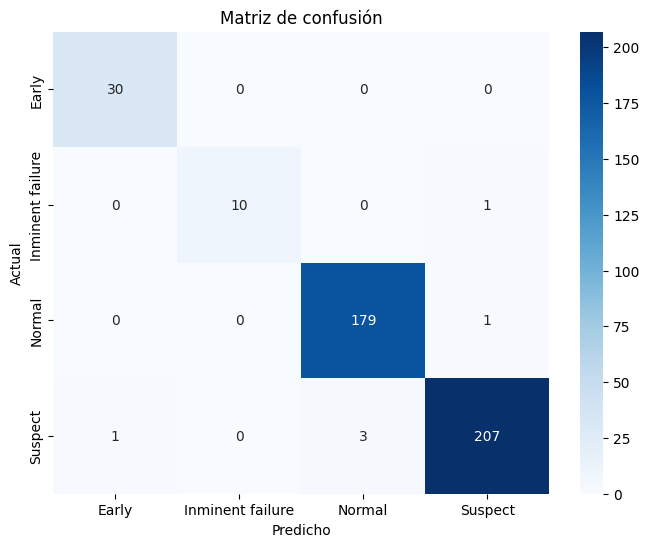

In [14]:

cm = confusion_matrix(y_test, y_pred)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.title("Matriz de confusión")
plt.ylabel("Actual")
plt.xlabel("Predicho")
plt.show()

# MK - CNN


In [43]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Flatten, Dropout

def make_build_model(X, num_classes):
    def build_model(hp):
        model = Sequential([
            Conv1D(
                filters=hp.Int('filters_1', min_value=16, max_value=128, step=16),
                kernel_size=hp.Choice('kernel_size_1', values=[2, 3, 5]),
                activation="relu",
                padding='same',
                input_shape=(X.shape[1], X.shape[2])
            ),
            MaxPooling1D(pool_size=2),
            Conv1D(
                filters=hp.Int('filters_2', min_value=32, max_value=256, step=32),
                kernel_size=hp.Choice('kernel_size_2', values=[2, 3, 5]),
                activation="relu",
                padding='same'
            ),
            Flatten(),
            Dense(
                units=hp.Int('dense_units', min_value=32, max_value=256, step=32),
                activation="relu"
            ),
            Dropout(
                rate=hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)
            ),
            Dense(num_classes, activation="softmax")
        ])
        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=hp.Float('lr', min_value=1e-4, max_value=1e-2, sampling='log')
            ),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy', F1MacroScore(num_classes=num_classes)]
        )
        return model
    return build_model

# Uso — pasás X_train y num_classes acá
tuner = kt.Hyperband(
    make_build_model(X_train, len(np.unique(y_train))),  
    objective=kt.Objective('val_f1_score', direction='max'),
    max_epochs=40,
    factor=3,
    directory='kt_results',
    project_name='cnn_vibraciones'
)

# Callback para detener early si no mejora
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

# Búsqueda
tuner.search(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    validation_split=0.2,
    callbacks=[stop_early]
)

# Ver resumen de los mejores resultados
tuner.results_summary()

# Obtener el mejor modelo
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
Mejores hiperparámetros encontrados:
  filters_1:   {best_hps.get('filters_1')}
  filters_2:   {best_hps.get('filters_2')}
  kernel_1:    {best_hps.get('kernel_size_1')}
  kernel_2:    {best_hps.get('kernel_size_2')}
  dense_units: {best_hps.get('dense_units')}
  dropout:     {best_hps.get('dropout')}
  lr:          {best_hps.get('lr')}
""")

Reloading Tuner from kt_results/cnn_vibraciones/tuner0.json
Results summary
Results in kt_results/cnn_vibraciones
Showing 10 best trials
Objective(name="val_f1_score", direction="max")

Trial 0067 summary
Hyperparameters:
filters_1: 128
kernel_size_1: 3
filters_2: 64
kernel_size_2: 2
dense_units: 32
dropout: 0.4
lr: 0.0015980108835268547
tuner/epochs: 14
tuner/initial_epoch: 5
tuner/bracket: 2
tuner/round: 1
tuner/trial_id: 0056
Score: 0.9618614912033081

Trial 0084 summary
Hyperparameters:
filters_1: 128
kernel_size_1: 5
filters_2: 32
kernel_size_2: 3
dense_units: 64
dropout: 0.2
lr: 0.00025529484165240227
tuner/epochs: 40
tuner/initial_epoch: 14
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0079
Score: 0.9582096338272095

Trial 0077 summary
Hyperparameters:
filters_1: 64
kernel_size_1: 3
filters_2: 192
kernel_size_2: 3
dense_units: 160
dropout: 0.5
lr: 0.001800627430497124
tuner/epochs: 14
tuner/initial_epoch: 0
tuner/bracket: 1
tuner/round: 0
Score: 0.9566235542297363

Trial 0048 

In [44]:
# Entrenar el modelo final con los mejores hiperparámetros
best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    validation_split=0.2,
    callbacks=[stop_early]
)

Epoch 1/40
173/173 [==============================] - 4s 7ms/step - loss: 0.5210 - accuracy: 0.7875 - f1_score: 0.7131 - val_loss: 0.4321 - val_accuracy: 0.8493 - val_f1_score: 0.7329
Epoch 2/40
173/173 [==============================] - 1s 5ms/step - loss: 0.2992 - accuracy: 0.8963 - f1_score: 0.8610 - val_loss: 0.2622 - val_accuracy: 0.9072 - val_f1_score: 0.9076
Epoch 3/40
173/173 [==============================] - 1s 5ms/step - loss: 0.2455 - accuracy: 0.9094 - f1_score: 0.8616 - val_loss: 0.2931 - val_accuracy: 0.9101 - val_f1_score: 0.8976
Epoch 4/40
173/173 [==============================] - 1s 7ms/step - loss: 0.1934 - accuracy: 0.9347 - f1_score: 0.9138 - val_loss: 0.2384 - val_accuracy: 0.9391 - val_f1_score: 0.9469
Epoch 5/40
173/173 [==============================] - 1s 5ms/step - loss: 0.1664 - accuracy: 0.9427 - f1_score: 0.8797 - val_loss: 0.2654 - val_accuracy: 0.9391 - val_f1_score: 0.9469
Epoch 6/40
173/173 [==============================] - 1s 6ms/step - loss: 0.1432

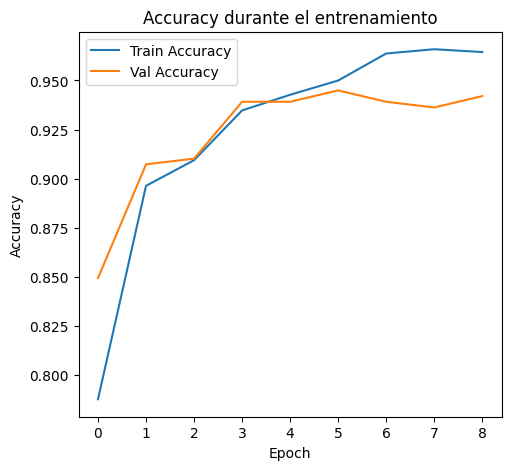

In [45]:
# mostrar grafico de accuracy y loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy durante el entrenamiento')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

In [46]:
# guardar el modelo entrenado 
best_model.save("./artefactos/cnn_mejorada.h5", save_format='h5')


/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Evaluacion

In [47]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = best_model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

14/14 [==============================] - 0s 3ms/step
Accuracy: 0.9560185185185185
                  precision    recall  f1-score   support

           Early       0.97      1.00      0.98        30
Inminent failure       0.85      1.00      0.92        11
          Normal       0.92      0.99      0.96       180
         Suspect       0.99      0.91      0.95       211

        accuracy                           0.96       432
       macro avg       0.93      0.98      0.95       432
    weighted avg       0.96      0.96      0.96       432



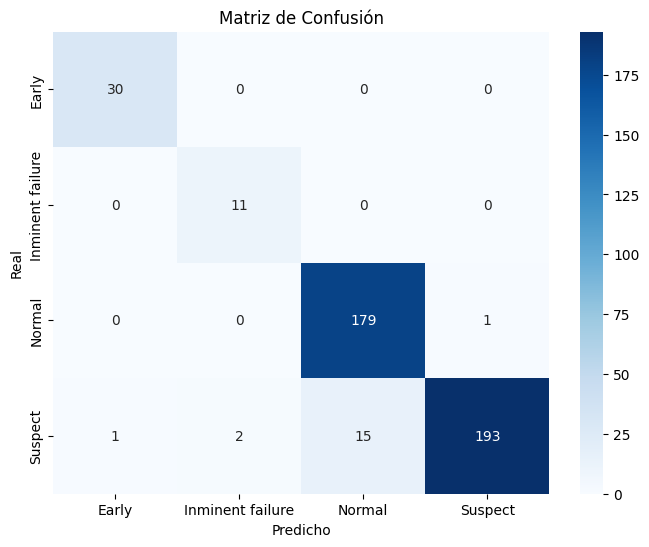

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión")

plt.show()

# RNN


In [24]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

def make_build_model(X_train, num_classes):
    def build_model(hp):
        model = Sequential([

            SimpleRNN(
                units=hp.Int('rnn_units_1', min_value=32, max_value=256, step=32),
                return_sequences=True,
                input_shape=(X_train.shape[1], X_train.shape[2])
            ),

            Dropout(
                rate=hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)
            ),

            SimpleRNN(
                units=hp.Int('rnn_units_2', min_value=16, max_value=128, step=16)
            ),

            Dense(
                units=hp.Int('dense_units', min_value=32, max_value=256, step=32),
                activation="relu"
            ),

            Dense(num_classes, activation="softmax")
        ])

        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=hp.Float('lr', min_value=1e-4, max_value=1e-2, sampling='log')
            ),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy",
                # tf.keras.metrics.Precision(name='precision'),
                # tf.keras.metrics.Recall(name='recall'),
                F1MacroScore(num_classes=num_classes)]
        )

        return model
    return build_model


tuner = kt.Hyperband(
    make_build_model(X_train, num_classes),
    objective=kt.Objective('val_f1_score', direction='max'),
    max_epochs=40,
    factor=3,
    directory='kt_results',
    project_name='rnn_vibraciones'
)

stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

tuner.search(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    validation_split=0.2,
    callbacks=[stop_early]
)

tuner.results_summary()

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
Mejores hiperparámetros encontrados:
  rnn_units_1: {best_hps.get('rnn_units_1')}
  rnn_units_2: {best_hps.get('rnn_units_2')}
  dropout:     {best_hps.get('dropout_1')}
  dense_units: {best_hps.get('dense_units')}
  lr:          {best_hps.get('lr')}
""")


Reloading Tuner from kt_results/rnn_vibraciones/tuner0.json
Results summary
Results in kt_results/rnn_vibraciones
Showing 10 best trials
Objective(name="val_f1_score", direction="max")

Trial 0061 summary
Hyperparameters:
rnn_units_1: 96
dropout_1: 0.4
rnn_units_2: 80
dense_units: 64
lr: 0.0007775212063831087
tuner/epochs: 14
tuner/initial_epoch: 5
tuner/bracket: 2
tuner/round: 1
tuner/trial_id: 0052
Score: 0.9650602340698242

Trial 0081 summary
Hyperparameters:
rnn_units_1: 128
dropout_1: 0.30000000000000004
rnn_units_2: 112
dense_units: 192
lr: 0.0004264401157975197
tuner/epochs: 40
tuner/initial_epoch: 0
tuner/bracket: 0
tuner/round: 0
Score: 0.9633245468139648

Trial 0078 summary
Hyperparameters:
rnn_units_1: 64
dropout_1: 0.5
rnn_units_2: 16
dense_units: 96
lr: 0.0004645769617789411
tuner/epochs: 40
tuner/initial_epoch: 14
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0074
Score: 0.9623860716819763

Trial 0080 summary
Hyperparameters:
rnn_units_1: 96
dropout_1: 0.1
rnn_units_2: 

In [25]:

# entrenar modelo final con mejores hiperparámetros
best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    validation_split=0.2,
    callbacks=[stop_early]
)

Epoch 1/40
173/173 [==============================] - 4s 12ms/step - loss: 0.4412 - accuracy: 0.8122 - f1_score: 0.7340 - val_loss: 0.3010 - val_accuracy: 0.8812 - val_f1_score: 0.8934
Epoch 2/40
173/173 [==============================] - 2s 11ms/step - loss: 0.2485 - accuracy: 0.9065 - f1_score: 0.9089 - val_loss: 0.2095 - val_accuracy: 0.9188 - val_f1_score: 0.9143
Epoch 3/40
173/173 [==============================] - 2s 11ms/step - loss: 0.1886 - accuracy: 0.9304 - f1_score: 0.9235 - val_loss: 0.1768 - val_accuracy: 0.9391 - val_f1_score: 0.9302
Epoch 4/40
173/173 [==============================] - 2s 11ms/step - loss: 0.1449 - accuracy: 0.9471 - f1_score: 0.9294 - val_loss: 0.1706 - val_accuracy: 0.9391 - val_f1_score: 0.9320
Epoch 5/40
173/173 [==============================] - 2s 11ms/step - loss: 0.1335 - accuracy: 0.9579 - f1_score: 0.9450 - val_loss: 0.1846 - val_accuracy: 0.9362 - val_f1_score: 0.9239
Epoch 6/40
173/173 [==============================] - 2s 11ms/step - loss: 

In [ ]:
# guardar el modelo entrenado 
best_model.save("./artefactos/rnn_mejorada.h5", save_format='h5')

/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Evaluación

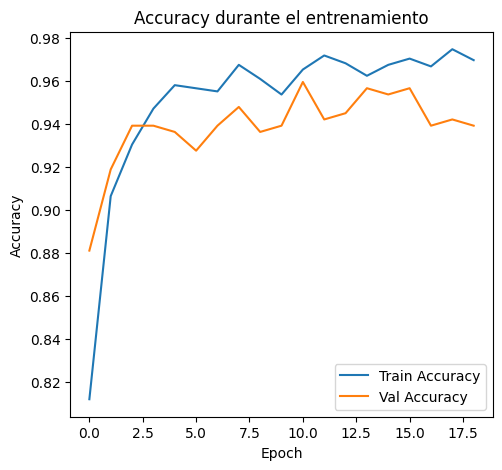

In [27]:
# mostrar grafico de accuracy y loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy durante el entrenamiento')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

In [28]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = best_model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

14/14 [==============================] - 0s 3ms/step
Accuracy: 0.9652777777777778
                  precision    recall  f1-score   support

           Early       0.97      1.00      0.98        30
Inminent failure       0.92      1.00      0.96        11
          Normal       0.96      0.97      0.96       180
         Suspect       0.98      0.95      0.96       211

        accuracy                           0.97       432
       macro avg       0.95      0.98      0.97       432
    weighted avg       0.97      0.97      0.97       432



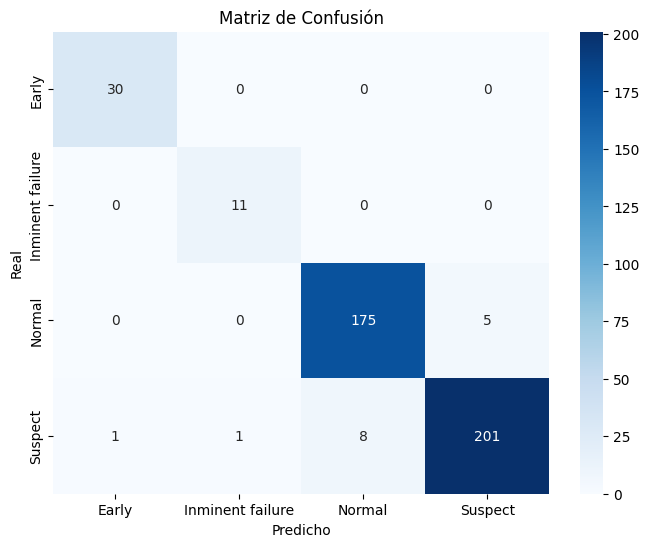

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión")

plt.show()

# LSTM

In [30]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

def make_build_model(X_train, num_classes):
    def build_model(hp):
        model = Sequential([

            LSTM(
                units=hp.Int('lstm_units_1', min_value=32, max_value=256, step=32),
                return_sequences=True,
                input_shape=(X_train.shape[1], X_train.shape[2])
            ),

            Dropout(
                rate=hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)
            ),

            LSTM(
                units=hp.Int('lstm_units_2', min_value=16, max_value=128, step=16)
            ),

            Dense(
                units=hp.Int('dense_units', min_value=32, max_value=256, step=32),
                activation="relu"
            ),

            Dense(num_classes, activation="softmax")
        ])

        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=hp.Float('lr', min_value=1e-4, max_value=1e-2, sampling='log')
            ),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy",
                # tf.keras.metrics.Precision(name='precision'),
                # tf.keras.metrics.Recall(name='recall'),
                F1MacroScore(num_classes=num_classes)]
        )

        return model
    return build_model


tuner = kt.Hyperband(
    make_build_model(X_train, num_classes),
    objective=kt.Objective('val_f1_score', direction='max'),
    max_epochs=40,
    factor=3,
    directory='kt_results',
    project_name='lstm_vibraciones'
)

stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

tuner.search(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    validation_split=0.2,
    callbacks=[stop_early]
)

tuner.results_summary()

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
Mejores hiperparámetros encontrados:
  lstm_units_1: {best_hps.get('lstm_units_1')}
  lstm_units_2: {best_hps.get('lstm_units_2')}
  dropout:      {best_hps.get('dropout_1')}
  dense_units:  {best_hps.get('dense_units')}
  lr:           {best_hps.get('lr')}
""")



Reloading Tuner from kt_results/lstm_vibraciones/tuner0.json
Results summary
Results in kt_results/lstm_vibraciones
Showing 10 best trials
Objective(name="val_f1_score", direction="max")

Trial 0086 summary
Hyperparameters:
lstm_units_1: 32
dropout_1: 0.4
lstm_units_2: 80
dense_units: 128
lr: 0.008326380697068002
tuner/epochs: 40
tuner/initial_epoch: 0
tuner/bracket: 0
tuner/round: 0
Score: 0.957563042640686

Trial 0083 summary
Hyperparameters:
lstm_units_1: 128
dropout_1: 0.1
lstm_units_2: 128
dense_units: 224
lr: 0.0005167397035568562
tuner/epochs: 40
tuner/initial_epoch: 14
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0074
Score: 0.9575486779212952

Trial 0084 summary
Hyperparameters:
lstm_units_1: 224
dropout_1: 0.5
lstm_units_2: 16
dense_units: 160
lr: 0.003687492934224323
tuner/epochs: 40
tuner/initial_epoch: 14
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0076
Score: 0.9575390219688416

Trial 0082 summary
Hyperparameters:
lstm_units_1: 128
dropout_1: 0.1
lstm_units_2: 128


In [31]:
best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=8,
    validation_split=0.2,
    callbacks=[stop_early]
)

Epoch 1/40
173/173 [==============================] - 4s 10ms/step - loss: 0.4525 - accuracy: 0.8209 - f1_score: 0.8060 - val_loss: 0.5398 - val_accuracy: 0.8058 - val_f1_score: 0.8367
Epoch 2/40
173/173 [==============================] - 1s 6ms/step - loss: 0.2619 - accuracy: 0.9130 - f1_score: 0.8694 - val_loss: 0.2636 - val_accuracy: 0.9014 - val_f1_score: 0.8819
Epoch 3/40
173/173 [==============================] - 1s 6ms/step - loss: 0.2093 - accuracy: 0.9355 - f1_score: 0.9137 - val_loss: 0.2165 - val_accuracy: 0.9362 - val_f1_score: 0.9239
Epoch 4/40
173/173 [==============================] - 1s 6ms/step - loss: 0.1440 - accuracy: 0.9521 - f1_score: 0.9199 - val_loss: 0.2059 - val_accuracy: 0.9217 - val_f1_score: 0.9159
Epoch 5/40
173/173 [==============================] - 1s 6ms/step - loss: 0.1493 - accuracy: 0.9550 - f1_score: 0.9495 - val_loss: 0.2888 - val_accuracy: 0.8986 - val_f1_score: 0.8562
Epoch 6/40
173/173 [==============================] - 1s 6ms/step - loss: 0.151

In [ ]:
# guardar el modelo entrenado 
best_model.save("./artefactos/lstm_mejorada.h5", save_format='h5')

/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Evaluación

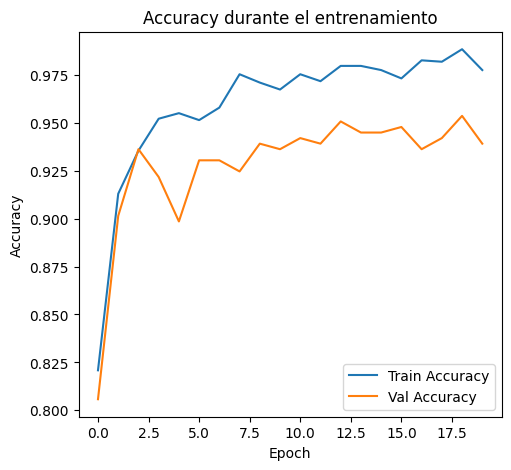

In [33]:
# mostrar grafico de accuracy y loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy durante el entrenamiento')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

In [34]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = best_model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

14/14 [==============================] - 1s 3ms/step
Accuracy: 0.9745370370370371
                  precision    recall  f1-score   support

           Early       0.97      1.00      0.98        30
Inminent failure       1.00      0.82      0.90        11
          Normal       0.96      0.99      0.98       180
         Suspect       0.99      0.96      0.97       211

        accuracy                           0.97       432
       macro avg       0.98      0.94      0.96       432
    weighted avg       0.97      0.97      0.97       432



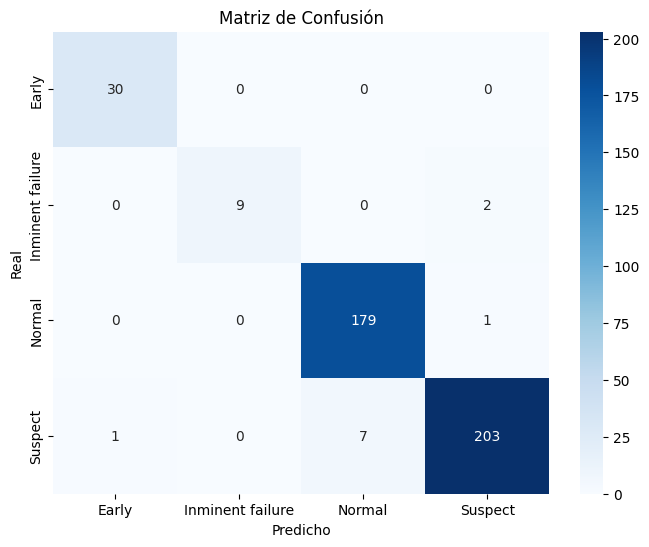

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión")

plt.show()

# Deep Neural Network

In [36]:
# Dado que este modelo espera una entrada 2D, necesitamos aplanar cada muestra de 8xfeatures a un vector de features. Esto se hace con reshape, manteniendo el número de muestras (X_train.shape[0]) y aplanando el resto (-1).
X_train_2d = X_train.reshape(X_train.shape[0], -1)
X_test_2d  = X_test.reshape(X_test.shape[0], -1)

print(X_train_2d.shape)  # (1724, 168)
print(X_test_2d.shape)   # (431, 168)

(1724, 168)
(432, 168)


In [37]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

def make_build_model(X_train, num_classes):
    num_features = X_train.shape[1] * X_train.shape[2]

    def build_model(hp):
        model = Sequential([

            Dense(
                units=hp.Int('dense_units_1', min_value=64, max_value=256, step=32),
                activation="relu",
                input_shape=(num_features,)
            ),

            Dense(
                units=hp.Int('dense_units_2', min_value=32, max_value=128, step=32),
                activation="relu"
            ),

            Dense(
                units=hp.Int('dense_units_3', min_value=16, max_value=64, step=16),
                activation="relu"
            ),

            Dropout(
                rate=hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)
            ),

            Dense(num_classes, activation="softmax")
        ])

        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=hp.Float('lr', min_value=1e-4, max_value=1e-2, sampling='log')
            ),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy",
                # tf.keras.metrics.Precision(name='precision'),
                # tf.keras.metrics.Recall(name='recall'),
                F1MacroScore(num_classes=num_classes)]
        )

        return model
    return build_model


tuner = kt.Hyperband(
    make_build_model(X_train, num_classes),
    objective=kt.Objective('val_f1_score', direction='max'),
    max_epochs=40,
    factor=3,
    directory='kt_results',
    project_name='mlp_vibraciones'
)

stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

# aplanar X a 2D antes de entrenar
X_train_2d = X_train.reshape(X_train.shape[0], -1)
X_val_2d   = X_test.reshape(X_test.shape[0], -1)

tuner.search(
    X_train_2d,
    y_train,
    epochs=40,
    batch_size=8,
    validation_data=(X_val_2d, y_test),
    callbacks=[stop_early]
)

tuner.results_summary()

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
Mejores hiperparámetros encontrados:
  dense_units_1: {best_hps.get('dense_units_1')}
  dense_units_2: {best_hps.get('dense_units_2')}
  dense_units_3: {best_hps.get('dense_units_3')}
  dropout:       {best_hps.get('dropout')}
  lr:            {best_hps.get('lr')}
""")



Reloading Tuner from kt_results/mlp_vibraciones/tuner0.json
Results summary
Results in kt_results/mlp_vibraciones
Showing 10 best trials
Objective(name="val_f1_score", direction="max")

Trial 0077 summary
Hyperparameters:
dense_units_1: 96
dense_units_2: 64
dense_units_3: 32
dropout: 0.5
lr: 0.0014825733072079664
tuner/epochs: 14
tuner/initial_epoch: 0
tuner/bracket: 1
tuner/round: 0
Score: 0.979971170425415

Trial 0087 summary
Hyperparameters:
dense_units_1: 128
dense_units_2: 64
dense_units_3: 64
dropout: 0.5
lr: 0.0038539501398167143
tuner/epochs: 40
tuner/initial_epoch: 0
tuner/bracket: 0
tuner/round: 0
Score: 0.979971170425415

Trial 0078 summary
Hyperparameters:
dense_units_1: 192
dense_units_2: 32
dense_units_3: 32
dropout: 0.1
lr: 0.0002401891792157938
tuner/epochs: 14
tuner/initial_epoch: 0
tuner/bracket: 1
tuner/round: 0
Score: 0.9786841869354248

Trial 0050 summary
Hyperparameters:
dense_units_1: 64
dense_units_2: 32
dense_units_3: 64
dropout: 0.30000000000000004
lr: 0.00199

In [38]:
best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(
    X_train_2d,
    y_train,
    epochs=40,
    batch_size=8,
    validation_data=(X_val_2d, y_test),
    callbacks=[stop_early]
)

Epoch 1/40
216/216 [==============================] - 2s 5ms/step - loss: 0.5804 - accuracy: 0.7715 - f1_score: 0.6892 - val_loss: 0.2500 - val_accuracy: 0.9051 - val_f1_score: 0.8913
Epoch 2/40
216/216 [==============================] - 1s 4ms/step - loss: 0.3097 - accuracy: 0.8950 - f1_score: 0.8464 - val_loss: 0.1772 - val_accuracy: 0.9259 - val_f1_score: 0.9359
Epoch 3/40
216/216 [==============================] - 1s 4ms/step - loss: 0.2124 - accuracy: 0.9292 - f1_score: 0.8952 - val_loss: 0.1493 - val_accuracy: 0.9468 - val_f1_score: 0.9296
Epoch 4/40
216/216 [==============================] - 1s 4ms/step - loss: 0.1841 - accuracy: 0.9443 - f1_score: 0.8974 - val_loss: 0.1204 - val_accuracy: 0.9560 - val_f1_score: 0.9348
Epoch 5/40
216/216 [==============================] - 1s 4ms/step - loss: 0.1485 - accuracy: 0.9466 - f1_score: 0.9266 - val_loss: 0.1059 - val_accuracy: 0.9699 - val_f1_score: 0.9585
Epoch 6/40
216/216 [==============================] - 1s 4ms/step - loss: 0.1405

In [39]:
# guardar el modelo entrenado 
best_model.save("./artefactos/dnn_mejorada.h5")

/home/marck/Documents/UBA/trabajo_final/TF_CEIA_Clasificador_Vibraciones/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Evaluación

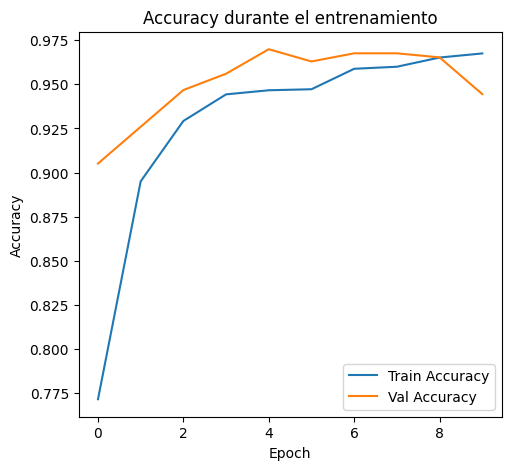

In [40]:
# mostrar grafico de accuracy y loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy durante el entrenamiento')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

In [41]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

y_pred = best_model.predict(X_test_2d)
y_pred = np.argmax(y_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

14/14 [==============================] - 0s 2ms/step
Accuracy: 0.9444444444444444
                  precision    recall  f1-score   support

           Early       0.97      1.00      0.98        30
Inminent failure       0.91      0.91      0.91        11
          Normal       0.96      0.92      0.94       180
         Suspect       0.93      0.96      0.94       211

        accuracy                           0.94       432
       macro avg       0.94      0.95      0.94       432
    weighted avg       0.95      0.94      0.94       432



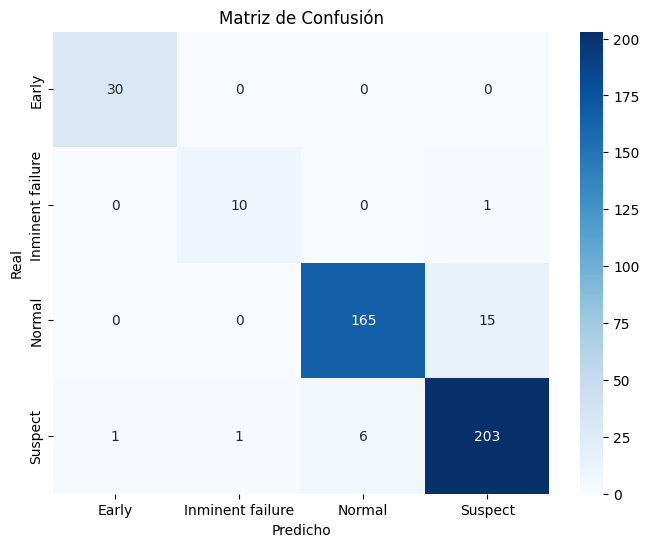

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión")

plt.show()